量子隐形传态（Quantum Teleportation）
=====================

本教程将带你了解量子信息领域一个广受欢迎的技术——量子隐形传态。虽然隐形传态常被认为是科幻小说中的内容，但我们将证明它在今天已经成为可能！这一技术利用了量子计算中许多基础原理，并在整个领域有广泛的应用。这些原理包括(但不限于)：不可克隆定理、量子纠缠和延迟测量原理。让我们一探究竟吧!

目标：传输量子信息
-----------------
假设有两位研究人员 Alice 和 Bob，Alice 想要将她的量子态发送给 Bob。量子隐形传态协议能够以一种非常优雅的方式实现这一点，整个过程可以分为四个步骤：

1. 态制备：Alice 将她的量子比特初始化为她希望传送的状态。

2. 共享纠缠：创建一个 Bell 态并分发给 Alice 和 Bob（每人一个量子比特）。

3. 基矢变换：Alice 将她的两个量子比特从 Bell 基矢转换到计算基矢。

4. 测量:Alice 测量她的两个量子比特，然后告诉 Bob 如何转换他的量子比特以获得期望的状态。请注意，传送的只是量子信息，而不是实际的粒子。


问题：不可克隆定理
-----------------

你可能会想，为什么我们需要传送量子态呢？Alice 不能直接复制一份然后发给 Bob 吗？事实上，复制任意量子态是被禁止的，这可以用不可克隆定理来解释。证明如下，假设我们想要设计一个线路（幺正变换）$U$，它可以执行以下操作：

$$\begin{aligned}
\begin{align*}
U(\vert \psi\rangle \otimes \vert s\rangle ) &= \vert \psi\rangle \otimes \vert \psi\rangle, \\
U(\vert \varphi\rangle \otimes \vert s\rangle ) &= \vert \varphi \rangle \otimes \vert \varphi \rangle,
\end{align*}
\end{aligned}$$

其中$\vert \psi\rangle$和$\vert \varphi\rangle$是任意归一化的单量子比特态，$\vert s \rangle$是某个任意的归一化初始态。我们现在来证明这样的 $U$ 是不存在的！

首先，让我们对等式左边取内积：

$$(\langle \psi \vert \otimes \langle s \vert) U^\dagger U(\vert \varphi\rangle \otimes \vert s\rangle ) = \langle \psi \vert \varphi\rangle \  \langle s \vert s\rangle$$

因为$\langle s \vert s\rangle$等于1，所以结果为$\langle \psi \vert \varphi \rangle$。接下来，我们比较等式右边的内积：$(\langle \psi \vert \varphi
\rangle)^2$。这两个内积必须相等，且只有当它们的值平方后仍等于自身时才成立。因此内积的取值只能是1或0。但如果内积为1，两个态是相同的；如果内积为0，两个态正交。所以，我们无法复制任意量子态！

解决方案：量子隐形传态
---------------------

现在我们将一步一步地演示如何在不复制的情况下共享量子信息。

### 1. 态制备

隐形传态涉及三个量子比特。其中两个由Alice持有，第三个由Bob持有。我们用下标表示它们的状态：

1.  $\vert\cdot\rangle_S$，Alice 的第一个量子比特，她将其制备成某个任意态
2.  $\vert\cdot\rangle_A$，Alice 的辅助量子比特，她将其与 Bob 的量子比特纠缠用于通信
3.  $\vert \cdot\rangle_B$，Bob 的量子比特，将接收传送过来的态

它们的初始态为：

$$\vert 0\rangle_S \vert 0\rangle_A \vert 0\rangle_B.$$

Alice 首先要做的是将她的第一个量子比特制备成她想要发送给 Bob 的任意态
$\vert \psi\rangle$，这样它们的联合态就变成了：

$$\vert \psi\rangle_S \vert 0\rangle_A \vert 0\rangle_B.$$

### 2. 共享纠缠

隐形传态之所以有效，是因为利用了一个 Alice 和 Bob 之间共享的纠缠态资源。可以想象有一个过程生成了一对纠缠的量子比特，并将它们一一发送给双方。为了简单起见，我们将把产生纠缠的过程表示为线路的一部分。

将量子比特 $A$ 和 $B$ 纠缠后，联合态变为：

$$\frac{1}{\sqrt{2}}\left( \vert \psi\rangle_S \vert 0\rangle_A \vert 0\rangle_B + \vert \psi\rangle_S \vert 1\rangle_A \vert 1\rangle_B \right)\tag{1}$$

现在 $AB$ 子系统处于一个所谓的 Bell 态。一共有四个极大纠缠的两量子比特 Bell 态，它们构成了 Bell 基：

$$\begin{aligned}
\begin{align*}
\vert \psi_+\rangle &= \frac{1}{\sqrt{2}} \left( \vert 00\rangle + \vert 11\rangle \right), \\
\vert \psi_-\rangle &= \frac{1}{\sqrt{2}} \left( \vert 00\rangle - \vert 11\rangle \right), \\
\vert \phi_+\rangle &= \frac{1}{\sqrt{2}} \left( \vert 01\rangle + \vert 10\rangle \right), \\
\vert \phi_-\rangle &= \frac{1}{\sqrt{2}} \left( \vert 01\rangle - \vert 10\rangle \right).
\end{align*}
\end{aligned}$$

在我们的实验中，因为 $AB$ 起始态为 $\vert 00\rangle$，所以我们制备的是 $\vert \psi_+\rangle$ Bell 态。为简洁起见，后面将省略量子态的下标。

### 3. 改变基底

传输协议的第三步是对前两个量子比特施加CNOT门和 Hadamard 门。这些操作在测量之前进行，被称为 "基底的改变"。但这指的是哪个基底呢？请注意，这两个量子门与我们创建 Bell 态时的操作恰好相反。如果反向运行它们，就能将基底转换回计算基底，从而模拟在 Bell 基底上的测量。

经过基底变换后，如果观测到前两个量子比特处于 $\vert 00\rangle$ 态，这就对应于 Bell 基底中的 $\vert \psi_+\rangle$ 态的结果；而 $\vert 11\rangle$ 则对应于 $\vert \phi_-\rangle$，以此类推。让我们逐步执行这个基底的改变。

设初始态 $\vert \psi\rangle$ 可以写成 $\alpha\vert 0\rangle + \beta\vert 1\rangle$ 的形式，其中 $\alpha$ 和 $\beta$ 是复数系数。展开式中的各项，可得：

$$\frac{1}{\sqrt{2}} ( \alpha\vert 000\rangle + \beta\vert 100\rangle + \alpha \vert 011\rangle + \beta\vert 111\rangle )$$

接下来，在 Alice 的两个量子比特之间施加一个 CNOT 门：

$$\frac{1}{\sqrt{2}} ( \alpha\vert 000\rangle + \beta\vert 110\rangle + \alpha \vert 011\rangle + \beta\vert 101\rangle )$$

然后对她的第一个量子比特施加 Hadamard 门：

$$\frac{1}{2} ( \alpha \vert 000\rangle + \alpha\vert 100\rangle + \beta\vert 010\rangle - \beta\vert 110\rangle + \alpha \vert 011\rangle + \alpha \vert 111 \rangle + \beta\vert 001\rangle - \beta\vert 101 \rangle )$$

现在我们需要进行一些重新整理。将与前两个量子比特相关的项组合在一起：

$$\frac{1}{2} \vert 00\rangle(\alpha\vert 0\rangle + \beta\vert 1\rangle) + \frac{1}{2}\vert 01\rangle (\beta\vert 0\rangle + \alpha\vert 1\rangle) + \frac{1}{2}\vert 10\rangle (\alpha\vert 0\rangle - \beta\vert 1\rangle) + \frac{1}{2}\vert 11\rangle (-\beta\vert 0\rangle + \alpha\vert 1\rangle).\tag{2}$$


### 4. 测量

协议的最后一步是 Alice 对她的量子比特进行测量，并根据测量结果告诉 Bob 进行某些操作。但为什么我们需要这样做呢？在前一步中，我们已经将基底旋转回了计算基底，难道还不够吗？不完全是，但也差不多了！

如果 Alice 在计算基底上测量她的两个量子比特，那么四种可能的结果出现的概率是相等的。如果她观测到前两个量子比特处于 $\vert 00 \rangle$ 态，就立即知道 Bob 的量子比特正处于我们想要传输的目标态 $\alpha \vert 0 \rangle + \beta \vert 1 \rangle$！

如果她观测到的是 $\vert 01\rangle$ 态，仍然能知道 Bob 的量子比特处于什么态，只不过与原态略有不同。具体来说：

$$\beta \vert 0 \rangle + \alpha \vert 1 \rangle = X \vert \psi \rangle$$

在得到这些结果后，Alice 可以告诉 Bob 对他的量子比特施加一个 X 门，就能恢复原始态。类似地，如果她得到的是 $\vert 10\rangle$ 态，就会让他施加一个 Z 门。

事实上，在量子隐形传态的 "传统" 版本中[1]，正是这么做的。Alice 会打电话给 Bob，告诉他她观测到了哪种态，然后他就能施加适当的校正。在这种情况下，测量发生在协议的中途，测量结果被用来控制后续量子门的应用。这就是所谓的中途测量(mid-circuit measurement)。

现在我们已经定义了量子隐形传态协议的所有基本组成部分。让我们把它们组合起来吧！

有一个巧妙的概念叫做测量延迟原理(principle of deferred measurement)[2]，它基本上说明我们可以将所有的测量都推迟到线路的最后进行。这在许多情况下都很有用，比如在不支持中途测量的系统中工作时。

测量延迟原理带给我们的一个方案 —— 我们可以用一个 CNOT 门代替 Alice 打电话告诉 Bob 施加 X 门，CZ 门也是同理。这非常有用，因为它让我们能在任何测量发生之前就完成校正。让我们评估一下 CNOT 门和 CZ 门对 Bob 的量子比特的作用，确保 Alice 的态已经成功传输。施加 CNOT 门后得到:

$$\frac{1}{2} \vert 00\rangle(\alpha\vert 0\rangle + \beta\vert 1\rangle) + \frac{1}{2}\vert 01\rangle (\alpha\vert 0\rangle + \beta\vert 1\rangle) + \frac{1}{2}\vert 10\rangle (\alpha\vert 0\rangle - \beta\vert 1\rangle) + \frac{1}{2}\vert 11\rangle (\alpha\vert 0\rangle - \beta\vert 1\rangle)$$

再施加 CZ 门后得到:

$$\frac{1}{2} \vert 00\rangle(\alpha\vert 0\rangle + \beta\vert 1\rangle) + \frac{1}{2}\vert 01\rangle (\alpha\vert 0\rangle + \beta\vert 1\rangle) + \frac{1}{2}\vert 10\rangle (\alpha\vert 0\rangle + \beta\vert 1\rangle) + \frac{1}{2}\vert 11\rangle (\alpha\vert 0\rangle + \beta\vert 1\rangle)\tag{3}$$

当 Alice 最后测量她的两个量子比特时，无论得到哪种结果，Bob 的量子比特都将处于 $\alpha\vert 0\rangle + \beta \vert 1\rangle$ 态。这意味着我们的协议已经将 Bob 的量子比特的状态变成了 Alice 想要发送的态！

我们将用它来验证 Alice 的态是否成功传输到了 Bob 的量子比特上。可以看到系统的最终态是:

$$\frac{1}{2} (\vert 00\rangle + \vert 01\rangle + \vert 10\rangle + \vert 11\rangle) \vert \psi\rangle\tag{4}$$

现在，通过比较 Bob 最终的密度矩阵与 Alice 最初的密度矩阵，我们可以确认量子隐形传态协议成功实现了。

以下是用DeepQuantum设计的量子隐形传态实验线路图：

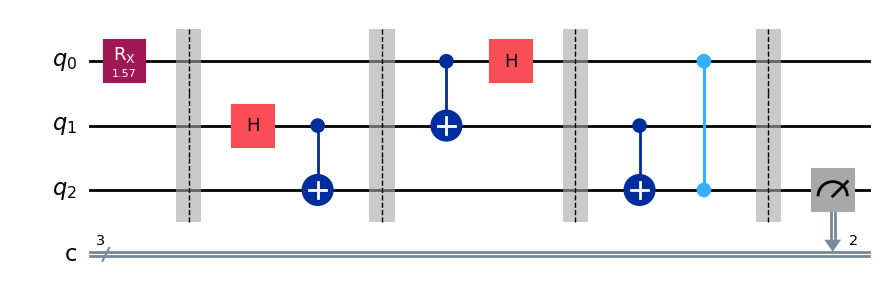

In [1]:
import deepquantum as dq
import numpy as np


def quantum_teleportation_circuit():
    cir = dq.QubitCircuit(3)

    # 1. 态制备
    cir.rx(0, np.pi / 2)
    cir.barrier()

    # 2. 共享纠缠
    cir.h(1)
    cir.cx(1, 2)
    cir.barrier()

    # 3. 改变基底
    cir.cx(0, 1)
    cir.h(0)
    cir.barrier()

    # 4. 测量延迟
    cir.cx(1, 2)
    cir.cz(0, 2)
    cir.measure(wires=2)
    cir.barrier()

    return cir


# 绘制量子线路图
teleportation_circuit = quantum_teleportation_circuit()
teleportation_circuit.draw()

结论
---------------------

让我们回顾一下在本教程中学到的概念。首先，我们确定由于 "不可克隆定理"，量子态不能被任意复制。然后，我们了解了 "量子纠缠"。一旦 Alice 和 Bob 共享了一对纠缠的量子比特，Alice 就对它们执行了从 Bell 基底到计算基底的 "基底变换"。最后，在需要时利用 "测量延迟原理"，Alice 测量了她的两个量子比特，并指导 Bob 如何将他的量子比特旋转到目标态。

就这样，Alice 和 Bob 通过一个相当小的线路完成了量子隐形传态。由于需要 Alice 向 Bob 进行经典通信，量子态（也就是信息）仍然无法以超过光速的速度被传送。当然，这并不会削弱量子隐形传态的重要性，这个协议是量子信息处理中的一个关键工具。

# 附录（References）

[1] Bennett C H, Brassard G, Crépeau C, et al. Teleporting an unknown quantum state via dual classical and Einstein-Podolsky-Rosen channels[J]. Physical review letters, 1993, 70(13): 1895.

[2] Nielsen M A, Chuang I L. Quantum computation and quantum information[M]. Cambridge university press, 2010.